# 11. Hyperparameter Search (Grid & Random) — Keras

Every earlier notebook fixed the hyperparameters. Here we *search* them. We run a **grid search** over learning rate × batch size, visualise the results as a heatmap, then contrast it with a **random search** over a wider space.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.21.0 | Keras 3.14.0


## 2. Load the data

In [2]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [3]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [4]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. A reusable train-and-score function

Each trial rebuilds the same architecture from the same seed and returns the best test accuracy — so differences come only from the hyperparameters. We keep epochs modest (40) because a search trains *many* models.

In [5]:
import itertools

def train_score(lr, batch_size, units=32, epochs=40):
    keras.utils.set_random_seed(42)
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(units, activation="relu"),
        layers.Dense(1,      activation="sigmoid"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(lr),
                  loss="binary_crossentropy", metrics=["accuracy"])
    h = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                  epochs=epochs, batch_size=batch_size, verbose=0)
    return max(h.history["val_accuracy"])

## 5. Grid search: learning rate × batch size

The classic exhaustive sweep — try **every** combination in the grid.

In [6]:
lr_grid    = [0.0003, 0.001, 0.003, 0.01]
batch_grid = [16, 32, 64]

records = []
for lr, bs in itertools.product(lr_grid, batch_grid):
    acc = train_score(lr, bs)
    records.append({"lr": lr, "batch_size": bs, "best_test_acc": acc})
    print("lr=%.4f  batch=%-3d -> best test acc = %.4f" % (lr, bs, acc))

grid_df = pd.DataFrame(records)
best = grid_df.loc[grid_df["best_test_acc"].idxmax()]
print("\nBest grid config: lr=%.4f, batch=%d -> acc=%.4f" %
      (best["lr"], best["batch_size"], best["best_test_acc"]))

lr=0.0003  batch=16  -> best test acc = 0.8455


lr=0.0003  batch=32  -> best test acc = 0.7967


lr=0.0003  batch=64  -> best test acc = 0.7236


lr=0.0010  batch=16  -> best test acc = 0.8618


lr=0.0010  batch=32  -> best test acc = 0.8618


...

lr=0.0030  batch=32  -> best test acc = 0.8618


lr=0.0030  batch=64  -> best test acc = 0.8618


lr=0.0100  batch=16  -> best test acc = 0.8618


lr=0.0100  batch=32  -> best test acc = 0.8618


lr=0.0100  batch=64  -> best test acc = 0.8618

Best grid config: lr=0.0010, batch=16 -> acc=0.8618


## 6. Heatmap of the grid

A pivot table makes the winning region obvious at a glance.

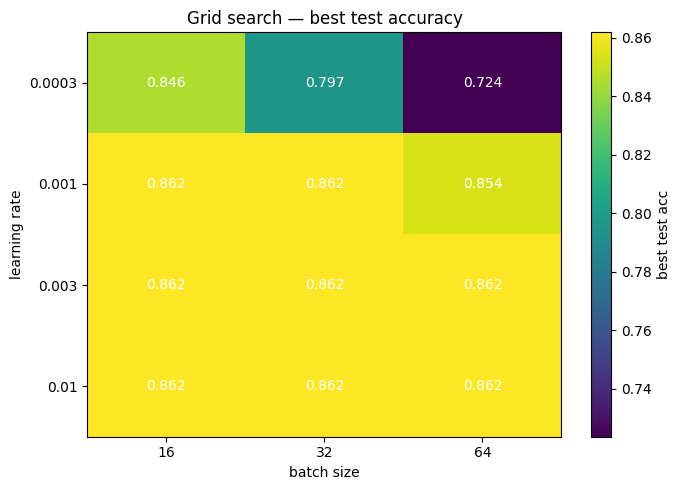

In [7]:
pivot = grid_df.pivot(index="lr", columns="batch_size", values="best_test_acc")

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
ax.set_xlabel("batch size"); ax.set_ylabel("learning rate")
ax.set_title("Grid search — best test accuracy")
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, "%.3f" % pivot.values[i, j], ha="center", va="center", color="w")
fig.colorbar(im, ax=ax, label="best test acc")
plt.tight_layout(); plt.show()

## 7. Random search

Grid cost explodes with dimensions. **Random search** samples configurations from ranges — with the same budget it usually explores the important dimensions better. We sample log-uniform learning rates so small and large rates get equal attention.

> `Date.now`/RNG seeding note: we build the candidate list deterministically with a fixed NumPy seed so the notebook re-runs identically.

In [8]:
rng = np.random.default_rng(0)          # fixed seed -> reproducible search
N_TRIALS = 8
unit_choices = [16, 32, 64]

rand_records = []
for t in range(N_TRIALS):
    lr = float(10 ** rng.uniform(-4, -2))     # log-uniform in [1e-4, 1e-2]
    bs = int(rng.choice([16, 32, 64]))
    units = int(rng.choice(unit_choices))
    acc = train_score(lr, bs, units=units)
    rand_records.append({"lr": round(lr, 5), "batch_size": bs, "units": units,
                         "best_test_acc": round(acc, 4)})
    print("trial %d: lr=%.5f batch=%-3d units=%-2d -> acc=%.4f" % (t, lr, bs, units, acc))

rand_df = pd.DataFrame(rand_records).sort_values("best_test_acc", ascending=False)
rand_df.reset_index(drop=True)

trial 0: lr=0.00188 batch=32  units=16 -> acc=0.8618


trial 1: lr=0.00012 batch=16  units=16 -> acc=0.7317


trial 2: lr=0.00423 batch=32  units=64 -> acc=0.8618


trial 3: lr=0.00163 batch=64  units=64 -> acc=0.8618


trial 4: lr=0.00122 batch=32  units=64 -> acc=0.8618


trial 5: lr=0.00428 batch=64  units=16 -> acc=0.8618


trial 6: lr=0.00519 batch=32  units=16 -> acc=0.8618


trial 7: lr=0.00288 batch=64  units=16 -> acc=0.8537


,lr,batch_size,units,best_test_acc
0,0.00188,32,16,0.8618
1,0.00423,32,64,0.8618
2,0.00163,64,64,0.8618
3,0.00122,32,64,0.8618
4,0.00519,32,16,0.8618
5,0.00428,64,16,0.8618
6,0.00288,64,16,0.8537
7,0.00012,16,16,0.7317


## 8. Best configuration found

In [9]:
best_grid = grid_df.loc[grid_df["best_test_acc"].idxmax()]
best_rand = rand_df.iloc[0]
print("Grid   best: lr=%.4f batch=%d           -> acc=%.4f" %
      (best_grid["lr"], best_grid["batch_size"], best_grid["best_test_acc"]))
print("Random best: lr=%.5f batch=%d units=%d  -> acc=%.4f" %
      (best_rand["lr"], best_rand["batch_size"], best_rand["units"], best_rand["best_test_acc"]))

Grid   best: lr=0.0010 batch=16           -> acc=0.8618
Random best: lr=0.00188 batch=32 units=16  -> acc=0.8618


## Takeaways
- **Grid search** is exhaustive and easy to reason about, but its cost is the *product* of every axis — it scales badly past 2–3 hyperparameters.
- **Random search** samples the space; with the same budget it typically finds configs as good or better, because it doesn't waste trials on an unimportant axis. Sampling learning rate **log-uniformly** is standard — orders of magnitude matter more than linear steps.
- Always score on the validation/test split and rebuild from a fixed seed, so a trial's score reflects the *hyperparameters*, not lucky initialization.
- For bigger searches, graduate to **KerasTuner** (Hyperband/Bayesian) — but the loop you wrote here is exactly what those tools automate.
- This wraps the series: you now have a baseline, every training technique, and a way to *tune* them.